# Numerical Solution of Ordinary Differential Equations in Python

**Author:** Alberto Reyes Castro  
**Original context:** Computational Physics coursework, BSc Physics  
**Public portfolio version:** translated and formatted for GitHub/Kaggle publication.

This notebook implements and compares numerical methods for solving ordinary differential equations (ODEs). It includes two one-step methods, a predictor-corrector method, comparison with `scipy.integrate.solve_ivp`, and a physical second-order ODE example based on simple harmonic motion.

The notebook does not require any external dataset.

## Project Aim

The aim of this notebook is to implement at least two one-step methods and one predictor-corrector method for the numerical solution of ordinary differential equations. The results are analysed and compared with SciPy's ODE integration tools.

The methods covered are:

- Euler method
- Modified Euler method
- Milne-Simpson predictor-corrector method
- SciPy `solve_ivp` using a Runge-Kutta method
- Modified Euler applied to a second-order physical ODE

## Problem 1: Carbon-14 Radioactive Decay

We want to calculate the remaining amount of a radioactive substance as it decays over time. The differential equation that governs this phenomenon is:

\begin{equation}
y'(t)=K\cdot y(t)
\end{equation}

where $K$ is a proportionality constant that depends on the substance, and $y(t)$ is the **remaining amount of substance** at time $t$. Therefore, $y(0)=y_0$ represents the initial amount of the substance.

The exact solution of this differential equation is:

\begin{equation}
y=y_0\cdot e^{K\cdot t}
\end{equation}

with:

\begin{equation}
K=-\frac{\ln(2)}{\tau}
\end{equation}

where $\tau$ is the half-life of the radioactive substance.

In this problem, the method is applied to Carbon-14 dating. The half-life of Carbon-14 is taken as 5600 years, and we want to estimate the age of an object for which **33.7% of the Carbon-14 has decayed**.

To solve this initial-value problem, we use $\tau=5600$ years, so:

\begin{equation}
K=-\frac{\ln(2)}{5600}
\end{equation}

Starting from the exact solution and solving for $t$:

\begin{equation}
t=\frac{1}{K}\ln\left(\frac{y}{y_0}\right)
\end{equation}

If the initial amount is 100%, then $y_0=1$ and $y(0)=1$.

The problem states that 33.7% of the radioactive substance has decayed. Since $y(t)$ represents the remaining amount of substance after time $t$, the remaining fraction is:

\begin{equation}
100\%-33.7\%=66.3\%
\end{equation}

Therefore:

\begin{equation}
y(t)=0.663
\end{equation}

We want to calculate the value of $t$ when $y=0.663$. Substituting into the exact solution:

\begin{equation}
t=\frac{-5600}{\ln(2)}\ln(0.663)=3320.347657\ldots \text{ years}
\end{equation}

The following sections implement several ODE methods and compare the numerical estimates with this exact value.

## One-Step Methods

### Euler Method

The Euler method is a simple one-step numerical method for solving ordinary differential equations (ODEs) with a given initial condition. It is a first-order method. Its local truncation error is proportional to $h^2$, while its global error is proportional to $h$, where $h$ is the step size.

Given a first-order differential equation with an initial condition:

\begin{equation}
y'=\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0
\end{equation}

the Euler method approximates the solution using discrete steps based on the derivative at the current point. The next approximation is calculated as:

\begin{equation}
y_{i+1} = y_i + h \cdot f(t_i, y_i)
\end{equation}

where $h$ is the step size and $t_i=t_0+i\cdot h$.

Euler's method is easy to implement and computationally inexpensive, but its accuracy is limited compared with higher-order methods.

In [1]:
# Import the required modules
import numpy as np
from scipy.integrate import solve_ivp

# Define the differential equation
def funcion(t, y, K):
    return K * y

# Initial parameters
objetivo_y = 0.663
umbral_error = 1e-5
h = 0.001
iteraciones_max = 10000000
y_o = 1
t_o = 0
tau = 5600
K = -np.log(2) / tau

# Exact analytical solution
solucion_exacta = ((-5600) / np.log(2)) * np.log(0.663)

# Euler method
def encontrar_tiempo_para_y_euler(objetivo_y, umbral_error, h, iteraciones_max):
    # Initialise the solution vector
    y = np.zeros(iteraciones_max + 1)
    y[0] = y_o

    # Iterate until the target value is reached or the maximum number of iterations is exceeded
    for i in range(0, iteraciones_max):
        # Calculate the next value using the Euler method
        y[i + 1] = y[i] + h * funcion(i * h, y[i], K)

        # Check whether the desired value has been reached within the selected tolerance
        if abs(y[i + 1] - objetivo_y) < umbral_error:
            # Return the time and the number of iterations required
            return i * h + h, i + 1

    # If no solution is found, return None
    return None, None

# SciPy solve_ivp method
def encontrar_t_ivp(objetivo_y, umbral_error, h, iteraciones_max):
    # Define the initial condition as a vector
    y0 = [1]

    # Define the system function for solve_ivp
    def fun(t, y, K):
        return [K * y[0]]

    # Event function to stop integration when the target value is reached
    def evento(t, y, K):
        return y[0] - objetivo_y

    evento.terminal = True

    # Solve using SciPy solve_ivp
    sol = solve_ivp(
        fun,
        (t_o, iteraciones_max * h),
        y0,
        args=(K,),
        events=evento,
        rtol=umbral_error,
        atol=umbral_error
    )

    # Check whether the target value was reached
    if sol.status == 1:
        # Return the time and an approximate number of steps
        return sol.t_events[0][0], sol.t[-1] // h

    # If no solution is found, return None
    return None, None

# Obtain results
tiempo_euler, iteracion_euler = encontrar_tiempo_para_y_euler(
    objetivo_y, umbral_error, h, iteraciones_max
)
tiempo_ivp, iteracion_ivp = encontrar_t_ivp(
    objetivo_y, umbral_error, h, iteraciones_max
)

# Print results
if (
    tiempo_euler is not None
    and iteracion_euler is not None
    and tiempo_ivp is not None
    and iteracion_ivp is not None
):
    # Calculate errors
    error1 = abs(tiempo_euler - tiempo_ivp)
    error2 = abs(solucion_exacta - tiempo_euler)
    error3 = abs(tiempo_ivp - solucion_exacta)

    print(
        f"For time step h={h} years, maximum iterations i={iteraciones_max}, "
        f"and error threshold={umbral_error}:"
    )
    print(f"The time associated with y={objetivo_y} using the Euler method is: {tiempo_euler}")
    print(f"The time associated with y={objetivo_y} using SciPy solve_ivp is: {tiempo_ivp}")
    print(f"The exact time associated with y={objetivo_y} is: {solucion_exacta}")
    print(f"The error between Euler and SciPy solve_ivp is: {error1}")
    print(f"The error between Euler and the exact solution is: {error2}")
    print(f"The error between SciPy solve_ivp and the exact solution is: {error3}")

else:
    print(
        "No time value was found for the desired y value. Try increasing the maximum "
        "number of iterations, decreasing h, or increasing the error threshold."
    )

For time step h=0.001 years, maximum iterations i=10000000, and error threshold=1e-05:
The time associated with y=0.663 using the Euler method is: 3320.226
The time associated with y=0.663 using SciPy solve_ivp is: 3320.3484136218926
The exact time associated with y=0.663 is: 3320.347657477196
The error between Euler and SciPy solve_ivp is: 0.12241362189251959
The error between Euler and the exact solution is: 0.12165747719609499
The error between SciPy solve_ivp and the exact solution is: 0.0007561446964245988


The Euler method has been implemented to solve the ODE, and the result is compared with `solve_ivp` from SciPy. In this notebook, `solve_ivp` is used as a more accurate reference implementation.

With the Euler method, the accuracy depends strongly on the step size $h$, the number of iterations, and the selected error threshold. These parameters must be changed carefully.

For example, if $h$ is increased too much, the method may skip over the target value $y=0.663$ and only pass near it within the selected threshold. This reduces precision. Similarly, if the maximum number of iterations is too low, the method may never reach the desired value. Increasing the error threshold makes it easier to find an approximate solution with lower computational cost, but this also increases the numerical error.

In summary, the Euler method can solve the problem, but it is less accurate than the SciPy Runge-Kutta-based implementation for the same tolerance.

### Modified Euler Method

The modified Euler method is an improved one-step method for solving ordinary differential equations. It provides better accuracy than the simple Euler method by using an additional function evaluation before computing the next value.

The implementation used here follows a Heun-type correction, where an Euler prediction is first made and then the slope is corrected using the average between the initial and predicted slopes:

\begin{equation}
y_{i+1}=y_i+\frac{h}{2}\left[f(t_i,y_i)+f(t_i+h,y_i+h f(t_i,y_i))\right]
\end{equation}

where $y_i$ is the current approximation, $h$ is the step size, and $f(t_i,y_i)$ defines the ODE.

The advantage of this method is that it uses more information about the slope across the interval $[t_i,t_{i+1}]$, which generally improves the approximation compared with the simple Euler method.

In [2]:
# Import the required modules
import numpy as np
from scipy.integrate import solve_ivp

# Define the differential equation
def funcion(t, y, K):
    return K * y

# Initial parameters
objetivo_y = 0.663
umbral_error = 1e-5
h = 0.001
iteraciones_max = 10000000
y_o = 1
tiempo_o = 0
tau = 5600
K = -np.log(2) / tau

# Exact analytical solution
solucion_exacta = ((-5600) / np.log(2)) * np.log(0.663)

# Modified Euler method
def encontrar_tiempo_para_y_euler_modificado(objetivo_y, umbral_error, h, iteraciones_max):
    # Initialise the solution vector
    y = np.zeros(iteraciones_max + 1)
    y[0] = y_o

    # Iterate until the target value is reached or the maximum number of iterations is exceeded
    for i in range(0, iteraciones_max):
        # Calculate intermediate values using the Euler prediction
        y_intermedio = y[i] + h * funcion(i * h, y[i], K)
        t_intermedio = (i + 1) * h

        # Calculate the next value using the modified Euler correction
        y[i + 1] = y[i] + (h / 2) * (
            funcion(i * h, y[i], K) + funcion(t_intermedio, y_intermedio, K)
        )

        # Check whether the desired value has been reached
        if abs(y[i + 1] - objetivo_y) < umbral_error:
            return i * h + h, i + 1

    # If no solution is found, return None
    return None, None

# SciPy solve_ivp method
def encontrar_t_ivp(objetivo_y, umbral_error, h, iteraciones_max):
    # Define the initial condition as a vector
    y0 = [1]

    # Define the system function for solve_ivp
    def fun(t, y, K):
        return [K * y[0]]

    # Event function to stop integration when the target value is reached
    def evento(t, y, K):
        return y[0] - objetivo_y

    evento.terminal = True

    # Solve using SciPy solve_ivp
    sol = solve_ivp(
        fun,
        (tiempo_o, iteraciones_max * h),
        y0,
        args=(K,),
        events=evento,
        rtol=umbral_error,
        atol=umbral_error
    )

    # Check whether the target value was reached
    if sol.status == 1:
        # Return the time and an approximate number of steps
        return sol.t_events[0][0], sol.t[-1] // h

    # If no solution is found, return None
    return None, None

# Obtain results
tiempo_euler_modificado, iteracion_euler_modificado = encontrar_tiempo_para_y_euler_modificado(
    objetivo_y, umbral_error, h, iteraciones_max
)
tiempo_ivp, iteracion_ivp = encontrar_t_ivp(objetivo_y, umbral_error, h, iteraciones_max)

# Calculate errors and print results if a valid solution is found
if (
    tiempo_euler_modificado is not None
    and iteracion_euler_modificado is not None
    and tiempo_ivp is not None
    and iteracion_ivp is not None
):
    error_metodos = abs(tiempo_euler_modificado - tiempo_ivp)
    error_eumod = abs(solucion_exacta - tiempo_euler_modificado)

    print(
        f"For time step h={h}, maximum iterations i={iteraciones_max}, "
        f"and error threshold={umbral_error}:"
    )
    print(
        f"The time associated with y={objetivo_y} using the modified Euler method is: "
        f"{tiempo_euler_modificado}"
    )
    print(f"The time associated with y={objetivo_y} using SciPy solve_ivp is: {tiempo_ivp}")
    print(f"The exact time associated with y={objetivo_y} is: {solucion_exacta}")
    print(f"The error between modified Euler and SciPy solve_ivp is: {error_metodos}")
    print(f"The error between modified Euler and the exact solution is: {error_eumod}")

else:
    print(
        "No time value was found for the desired y value. Try increasing the maximum "
        "number of iterations, decreasing h, or increasing the error threshold."
    )

For time step h=0.001, maximum iterations i=10000000, and error threshold=1e-05:
The time associated with y=0.663 using the modified Euler method is: 3320.226
The time associated with y=0.663 using SciPy solve_ivp is: 3320.3484136218926
The exact time associated with y=0.663 is: 3320.347657477196
The error between modified Euler and SciPy solve_ivp is: 0.12241362189251959
The error between modified Euler and the exact solution is: 0.12165747719609499


Although the modified Euler method is more accurate than the simple Euler method in general, its performance still depends on the form of the function, the initial conditions, the step size $h$, the number of iterations, and the selected error threshold.

In this specific target-detection setup, the reported time is still affected by the step size and tolerance used to detect when $y$ reaches 0.663. The SciPy method remains much closer to the exact analytical solution.

### Comparison of the One-Step Methods

The main advantages and limitations of the two one-step methods are summarised below.

**Simple Euler method**

**Advantages**

- Easy to understand and implement.
- Low computational cost per step.
- Useful as a first approach to numerical ODE solving.

**Limitations**

- Low accuracy because it is a first-order method.
- Global error is proportional to the step size $h$.
- Limited numerical stability for some problems, especially when $h$ is large.

**Modified Euler method**

**Advantages**

- More accurate than the simple Euler method.
- Uses an additional slope estimate to improve the approximation.
- Usually provides better stability than the simple Euler method.

**Limitations**

- Requires more function evaluations per step.
- Still depends strongly on the step size and tolerance.
- More accurate methods, such as Runge-Kutta methods, are usually preferred for high-precision calculations.

## Predictor-Corrector Methods

### Milne-Simpson Predictor-Corrector Method

The Milne-Simpson method combines a predictor step with a corrector step. In this implementation, a Milne-style formula is used to predict the next approximation, and a Simpson-style correction is then applied.

Predictor-corrector methods are useful because they first estimate a future value and then refine it using additional information from the differential equation.

For an ordinary differential equation of the form:

\begin{equation}
y'(t)=f(t,y)
\end{equation}

the predictor estimates $y_{i+1}$, and the corrector improves that estimate using a quadrature-based expression. Since this type of method requires previous values of the solution, initial approximations must first be generated using a one-step method such as Euler.

This section applies the predictor-corrector approach to the same Carbon-14 radioactive decay problem.

In [3]:
# Import the required modules
import numpy as np
from scipy.integrate import solve_ivp

# Define the differential equation
def funcion(t, y, K):
    return K * y

# Initial parameters
objetivo_y = 0.663
umbral_error = 1e-5
h = 0.001
iteraciones_max = 10000000
y_o = 1
tiempo_o = 0
tau = 5600
K = -np.log(2) / tau

# Exact analytical solution
solucion_exacta = ((-5600) / np.log(2)) * np.log(0.663)

# Milne-Simpson predictor-corrector method
def encontrar_t_MS(objetivo_y, umbral_error, h, iteraciones_max):
    # Initialise the solution vector
    y = np.zeros(iteraciones_max + 1)
    y[0] = y_o

    # Use the simple Euler method to obtain the first approximations needed by the rule
    y[1] = y[0] + h * funcion(0, y[0], K)
    y[2] = y[1] + h * funcion(h, y[1], K)

    # Iterate until the target value is reached or the maximum number of iterations is exceeded
    for i in range(2, iteraciones_max):
        # Milne predictor
        y_predicha = y[i - 2] + 4 / 3 * h * (
            2 * funcion((i - 1) * h, y[i - 1], K)
            - funcion((i - 2) * h, y[i - 2], K)
        )

        # Simpson corrector
        y[i + 1] = y[i - 1] + h / 3 * (
            funcion(i * h, y_predicha, K)
            + 4 * funcion((i - 1) * h, y[i - 1], K)
            + funcion((i - 2) * h, y[i - 2], K)
        )

        # Check whether the desired value has been reached
        if abs(y[i + 1] - objetivo_y) < umbral_error:
            return i * h + h, i + 1

    # If no solution is found, return None
    return None, None

# SciPy solve_ivp method
def encontrar_t_ivp(objetivo_y, umbral_error, h, iteraciones_max):
    # Define the initial condition as a vector
    y0 = [1]

    # Define the system function for solve_ivp
    def fun(t, y, K):
        return [K * y[0]]

    # Event function to stop integration when the target value is reached
    def evento(t, y, K):
        return y[0] - objetivo_y

    evento.terminal = True

    # Solve using SciPy solve_ivp
    sol = solve_ivp(
        fun,
        (tiempo_o, iteraciones_max * h),
        y0,
        args=(K,),
        events=evento,
        rtol=umbral_error,
        atol=umbral_error
    )

    # Check whether the target value was reached
    if sol.status == 1:
        # Return the time and an approximate number of steps
        return sol.t_events[0][0], sol.t[-1] // h

    # If no solution is found, return None
    return None, None

# Obtain results
tiempo_MS, iteracion_MS = encontrar_t_MS(objetivo_y, umbral_error, h, iteraciones_max)
tiempo_ivp, iteracion_ivp = encontrar_t_ivp(objetivo_y, umbral_error, h, iteraciones_max)

# Calculate errors and print results
if tiempo_MS is not None and iteracion_MS is not None:
    error_MS = abs(solucion_exacta - tiempo_MS)

    print(
        f"For time step h={h} years, maximum iterations i={iteraciones_max}, "
        f"and error threshold={umbral_error}:"
    )
    print(
        f"The time associated with y={objetivo_y} using the Milne-Simpson method is: "
        f"{tiempo_MS}"
    )
    print(f"The time associated with y={objetivo_y} using SciPy solve_ivp is: {tiempo_ivp}")
    print(f"The exact time associated with y={objetivo_y} is: {solucion_exacta}")
    print(f"The error between Milne-Simpson and the exact solution is: {error_MS}")
else:
    print(
        "No time value was found for the desired y value. Try increasing the maximum "
        "number of iterations, decreasing h, or increasing the error threshold."
    )

For time step h=0.001 years, maximum iterations i=10000000, and error threshold=1e-05:
The time associated with y=0.663 using the Milne-Simpson method is: 3320.226
The time associated with y=0.663 using SciPy solve_ivp is: 3320.3484136218926
The exact time associated with y=0.663 is: 3320.347657477196
The error between Milne-Simpson and the exact solution is: 0.12165747719609499


**Milne-Simpson predictor-corrector method**

**Advantages**

- It can provide high accuracy for suitable ODE problems.
- It combines prediction and correction, improving the initial estimate of the next value.
- It is relatively efficient and not too difficult to implement.

**Limitations**

- It can be unstable for some problems, especially nonlinear or stiff systems.
- It requires previous solution values, so it cannot start without another method such as Euler.
- It may require a significant number of function evaluations to reach the desired accuracy.
- Its accuracy can decrease in the presence of discontinuities or singularities.

## Problem 2: Second-Order Physical ODE

We now formulate and solve a physical problem represented by a second-order differential equation.

A standard example is **simple harmonic motion**, such as a mass attached to a spring. In this case, the restoring force is proportional to the displacement from equilibrium. The system can be modelled as:

\begin{equation}
m \cdot \frac{d^2x}{dt^2} = -k \cdot x
\end{equation}

where $m$ is the mass, $k$ is the spring constant, and $x(t)$ is the position of the object as a function of time.

To solve this second-order ODE using the modified Euler method, the equation is decomposed into two first-order equations. We define:

\begin{equation}
v=\frac{dx}{dt}
\end{equation}

so that:

\begin{equation}
\frac{dv}{dt}=-\frac{k}{m}\cdot x
\end{equation}

The time variable is then discretised using a step size $h$, and the modified Euler method is applied to approximate both $x$ and $v$ at each time step.

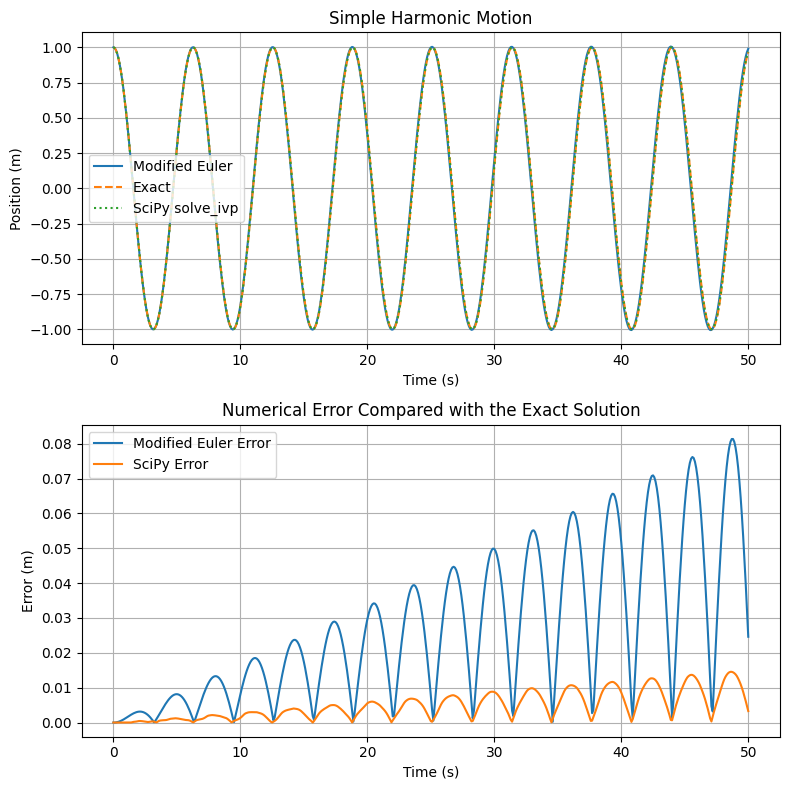

In [4]:
# Import the required modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters: mass, spring constant, initial position and initial velocity
m = 1
k = 1
x0 = 1
v0 = 0

# Time parameters: initial time, final time and time step
t0 = 0
tf = 50
h = 0.1

# Functions used to calculate the derivatives
def f(t, x, v):
    return v

def g(t, x, v):
    return -k / m * x

# Modified Euler method
t = np.arange(t0, tf + h, h)
x = np.zeros_like(t)
v = np.zeros_like(t)
x[0] = x0
v[0] = v0

for i in range(len(t) - 1):
    # Calculate intermediate values of x and v using the modified Euler method
    x_intermedio = x[i] + 0.5 * h * v[i]
    v_intermedio = v[i] + 0.5 * h * g(t[i], x[i], v[i])

    x[i + 1] = x[i] + h * v_intermedio
    v[i + 1] = v[i] + h * g(t[i] + h / 2, x_intermedio, v_intermedio)

# Calculate the exact position for each time value
omega = np.sqrt(k / m)
x_exacta = x0 * np.cos(omega * t)

# Solution with SciPy solve_ivp
def f(t, y):
    x, v = y
    return [v, -k / m * x]

t_eval = np.linspace(t0, tf, 1000)
sol = solve_ivp(f, [t0, tf], [x0, v0], method="RK45", t_eval=t_eval)
x_rk5 = np.interp(t, sol.t, sol.y[0])

# Calculate the error of modified Euler and SciPy with respect to the exact solution
error_euler_mod = np.abs(x_exacta - x)
error_rk5 = np.abs(x_rk5 - x_exacta)

# Plot position as a function of time and numerical error
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

ax[0].plot(t, x, label="Modified Euler")
ax[0].plot(t, x_exacta, "--", label="Exact")
ax[0].plot(t, x_rk5, ":", label="SciPy solve_ivp")
ax[0].set_title("Simple Harmonic Motion")
ax[0].grid()
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Position (m)")
ax[0].legend()

ax[1].plot(t, error_euler_mod, label="Modified Euler Error")
ax[1].plot(t, error_rk5, label="SciPy Error")
ax[1].set_title("Numerical Error Compared with the Exact Solution")
ax[1].grid()
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Error (m)")
ax[1].legend()

plt.tight_layout()
plt.show()

The general solution of the second-order differential equation:

\begin{equation}
m \cdot \frac{d^2x}{dt^2} = -k \cdot x
\end{equation}

can be obtained by assuming a solution of the form:

\begin{equation}
x(t)=A\cos(\omega t + \phi)
\end{equation}

Taking derivatives:

\begin{align}
\frac{dx}{dt} &= -A\omega \sin(\omega t + \phi) \\
\frac{d^2x}{dt^2} &= -A\omega^2 \cos(\omega t + \phi)
\end{align}

Substituting into the original equation:

\begin{equation}
-mA\omega^2\cos(\omega t + \phi)=-kA\cos(\omega t + \phi)
\end{equation}

and simplifying:

\begin{equation}
\omega=\sqrt{\frac{k}{m}}
\end{equation}

Therefore, the exact solution is:

\begin{equation}
x(t)=A\cos\left(\sqrt{\frac{k}{m}}t+\phi\right)
\end{equation}

For the parameters used here, $\phi=0$ and $A=x_0=1$, since $x(0)=1$.

The modified Euler method and SciPy's Runge-Kutta-based solver both approximate the exact solution reasonably well for the selected step size.

As time increases, the numerical error also increases, but the growth is not too significant over the selected interval. To observe larger differences, a longer time interval or a larger step size would be needed.

Since the simple harmonic oscillator is periodic, its period is:

\begin{equation}
T=\frac{2\pi}{\omega}=\frac{2\pi}{\sqrt{k/m}}=2\pi\sqrt{\frac{m}{k}}
\end{equation}

This means that the same pattern repeats over later intervals. For this reason, studying the approximate solutions over one or several periods provides useful information about the numerical behaviour of the methods.

## Conclusion

This notebook implemented several numerical methods for ordinary differential equations and compared them against exact analytical solutions and SciPy's `solve_ivp`.

The main observations are:

- Euler's method is simple and computationally cheap, but less accurate.
- The modified Euler method improves the slope estimate and generally provides better numerical behaviour.
- Predictor-corrector methods can improve approximations, but they require previous values and may have stability limitations.
- SciPy's `solve_ivp` provides a strong reference implementation based on more advanced adaptive Runge-Kutta methods.
- For physical systems such as the simple harmonic oscillator, numerical error can accumulate over time, making step-size selection important.

Overall, the notebook shows how classical numerical methods can be implemented directly in Python and compared with modern scientific computing libraries.